In [50]:
# Loading libraries
suppressPackageStartupMessages({
    library(tidyverse) # Give ggplot, read_delim, tidyr, etc.
    library(janitor) # Gives tabyl
    library(gplots) # Gives plotmeans
    library(ggstatsplot) # Gives pretty plotting
    library(car) # Gives Anova
    library(Hmisc) # Gives mean_cl_boot
    library(dplyr) # Gives join, mutate, filter, etc.
})
options(width=200) # set the display width to 200 characters


### Loading and cleaning data

In [51]:
load_questionnaire_data <- function(file_path) {
  # Read CSV
  df <- read.csv(file_path, check.names = FALSE)

  # Drop unwanted columns
  df <- df %>% select(
    -c(
      Surname,
      `First name`,
      State,
      `Started on`,
      Completed,
      `Grade/10.00`,
      `Time taken`,
    )
  )

  # Rename columns
  df <- df %>%
    rename(
      email = `Email address`,
      gender = `Response 1`,
      age = `Response 2`,
      academic_level = `Response 3`,
      academic_field = `Response 4`,
      parents_education = `Response 5`,
      sport = `Response 6`
    )

  return(df)
}


load_pretest_data <- function(file_path) {
  # Read CSV
  df <- read.csv(file_path, check.names = FALSE)

  # Keep and rename specific columns
  df <- df %>%
    select(
      email = `Email address`,
      time_pretest = `Time taken`,
      grade_pretest = `Grade/9.00`
    )

  return(df)
}

load_posttest1_data <- function(file_path) {
  # Read CSV
  df <- read.csv(file_path, check.names = FALSE)

  # Keep and rename specific columns
  df <- df %>%
    select(
      email = `Email address`,
      time_posttest = `Time taken`,
      grade_posttest = `Grade/9.00`
    )

  return(df)
}

load_posttest2_data <- function(file_path) {
  # Read CSV
  df <- read.csv(file_path, check.names = FALSE)

  # Drop unwanted columns
  df <- df %>% select(
    -c(
      Surname,
      `First name`,
      State,
      `Started on`,
      Completed,
      `Grade/7.00`,
      `Time taken`
    )
  )

  # Rename columns
  df <- df %>%
    rename(
      email = `Email address`,
      comfort_before       = `Response 1`,
      comfort_after        = `Response 2`,
      comfort_explanation  = `Response 3`,
      confidence           = `Response 4`,
      perceived_learning   = `Response 5`,
      learning_explanation = `Response 6`,
      comments             = `Response 7`
    )

  return(df)
}

convert_time_to_seconds <- function(time_str) {
  mins <- as.numeric(str_extract(time_str, "\\d+(?=\\s*mins?)"))
  secs <- as.numeric(str_extract(time_str, "\\d+(?=\\s*secs?)"))
  mins[is.na(mins)] <- 0
  secs[is.na(secs)] <- 0
  total_seconds <- mins * 60 + secs
  return(total_seconds)
}

In [52]:
# Load data from csv files
questionnaire_psi = load_questionnaire_data("data/questionnaire_psi.csv")
questionnaire_ips = load_questionnaire_data("data/questionnaire_ips.csv")
pretest_psi = load_pretest_data("data/pretest_psi.csv")
pretest_ips = load_pretest_data("data/pretest_ips.csv")
posttest1_psi = load_posttest1_data("data/posttest1_psi.csv")
posttest1_ips = load_posttest1_data("data/posttest1_ips.csv")
posttest2_psi = load_posttest2_data("data/posttest2_psi.csv")
posttest2_ips = load_posttest2_data("data/posttest2_ips.csv")

In [53]:
# PSI group
psi_data <- posttest1_psi %>%
  inner_join(questionnaire_psi, by = "email") %>%
  left_join(pretest_psi, by = "email") %>%
  left_join(posttest2_psi, by = "email") %>%
  mutate(group = "psi") %>%
  select(-email)

# IPS group
ips_data <- posttest1_ips %>%
  inner_join(questionnaire_ips, by = "email") %>%
  left_join(pretest_ips, by = "email") %>%
  left_join(posttest2_ips, by = "email") %>%
  mutate(group = "ips") %>%
  select(-email)


psi_data$grade_pretest <- as.numeric(psi_data$grade_pretest)
ips_data$grade_pretest <- as.numeric(ips_data$grade_pretest)

# Combine both
final_data <- bind_rows(psi_data, ips_data)

final_data <- final_data %>%
  mutate(
    time_pretest = convert_time_to_seconds(time_pretest),
    time_posttest = convert_time_to_seconds(time_posttest), 
  )

# Save the final data
write.csv(final_data, "data/final_data.csv", row.names = FALSE)
# Print the first few rows of the final data
print(head(final_data))

  time_posttest grade_posttest gender                    age academic_level                                 academic_field parents_education
1           471            9.0 Female        18-22 years old         Master                               Computer Science        University
2           354            9.0   Male        18-22 years old         Master       Computer Science (and Math for bachelor)       High school
3           307            9.0   Male More than 25 years old         Master                            Applied Mathematics        University
4           388            6.1 Female More than 25 years old       Bachelor Environmental Laws and International Relations       High school
5           534            5.5   Male        23-25 years old       Bachelor                               Computer Science        University
6           369            6.5 Female More than 25 years old       Bachelor                          Environmental Science        University
             

### Dependent variable: Relative learning gain

In [54]:
# Calculate the relative learning gain
calculate_rlg = function(df, pre_col = "grade_pretest", post_col = "grade_posttest", max_score = 9) {
  df = df %>%
    mutate(
      !!pre_col := as.numeric(.data[[pre_col]]),
      !!post_col := as.numeric(.data[[post_col]]),
      rel_learning_gain = round((.data[[post_col]] - .data[[pre_col]]) / (max_score - .data[[pre_col]]), 2)
    )
  return(df)
}

df_combined = calculate_rlg(final_data)

head(df_combined)


,time_posttest,grade_posttest,gender,age,academic_level,academic_field,parents_education,sport,time_pretest,grade_pretest,comfort_before,comfort_after,comfort_explanation,confidence,perceived_learning,learning_explanation,comments,group,rel_learning_gain
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,471,9.0,Female,18-22 years old,Master,Computer Science,University,Gym 2-3 times a week,259,7.0,4,5,"I felt unsure during the pre-test because, while I have seen Dijkstra before, I forgot how the algorithm worked and could not answer the questions that required an understanding of the exact steps before watching the video (e.g. which node is processed when). It was easy to answer the questions where you just have to find the shortest path because it doesn't require an understanding of Dijkstra in particular.",Somewhat Confident,Definitely,I learn best by following examples which the instruction provided.,-,psi,1.00
2,354,9.0,Male,18-22 years old,Master,Computer Science (and Math for bachelor),High school,"Ultimate frisbee and Bouldering, about once a week in total",353,7.0,NA,NA,NA,NA,NA,NA,NA,psi,1.00
3,307,9.0,Male,More than 25 years old,Master,Applied Mathematics,University,Yes. Running twice a week,227,5.5,3,5,in the lesson i learned about the detailed steps of the algorithm,Somewhat Confident,Definitely,the video was clear,-,psi,1.00
4,388,6.1,Female,More than 25 years old,Bachelor,Environmental Laws and International Relations,High school,Long Walks- twice a week,601,1.2,3,4,The video explanation being in parts would have made understanding the new concept easier.,Not Very Confident,Definitely,The different methods to solve one problem is efficient in understanding a new concept.,Great Work! I would like to see the same conducted on a hybrid system where some tests are done to asses knowledge level before access to the content and then tests after the content.,psi,0.63
5,534,5.5,Male,23-25 years old,Bachelor,Computer Science,University,Yes. I normally do morning runs every Saturday of the week.,602,4.5,2,4,This is because I gathered more insights on the Dijkstra's algorithm through the video explanation.,Confident,Not so sure,This was a new topic unrelated to sorting lists I had done before,Good challenge for sure.,psi,0.22
6,369,6.5,Female,More than 25 years old,Bachelor,Environmental Science,University,"Walks, at least twice a week",487,4.2,3,5,"Before the activity, i had no idea what Dijkstra's algorithm was and how to use it, but for the post test it was a bit more clearer",Somewhat Confident,Kind of,"Since the topic is new to me, i learnt some things, but there was no way to clarify my confusion",-,psi,0.48


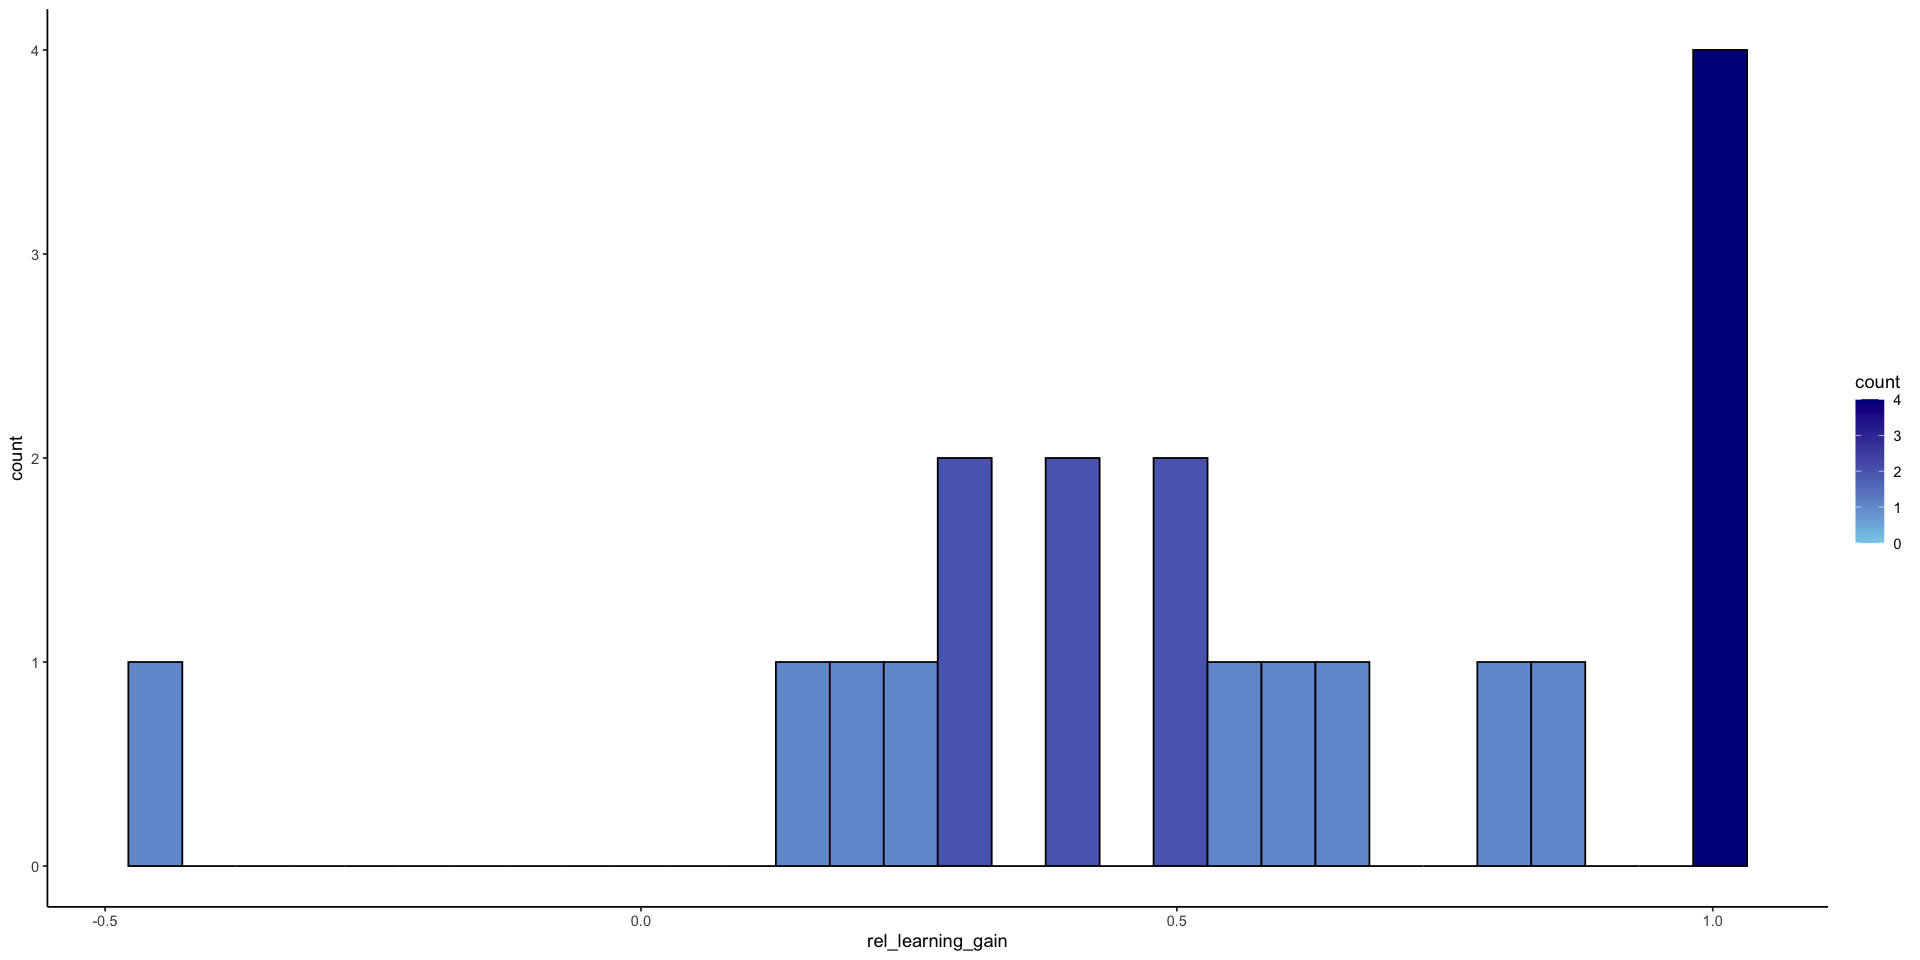

In [55]:
df_combined %>%
  ggplot(aes(x = rel_learning_gain, fill = ..count..)) +
  geom_histogram(bins = 30, color = "black") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  theme_classic()

### Descriptive statistics and plots

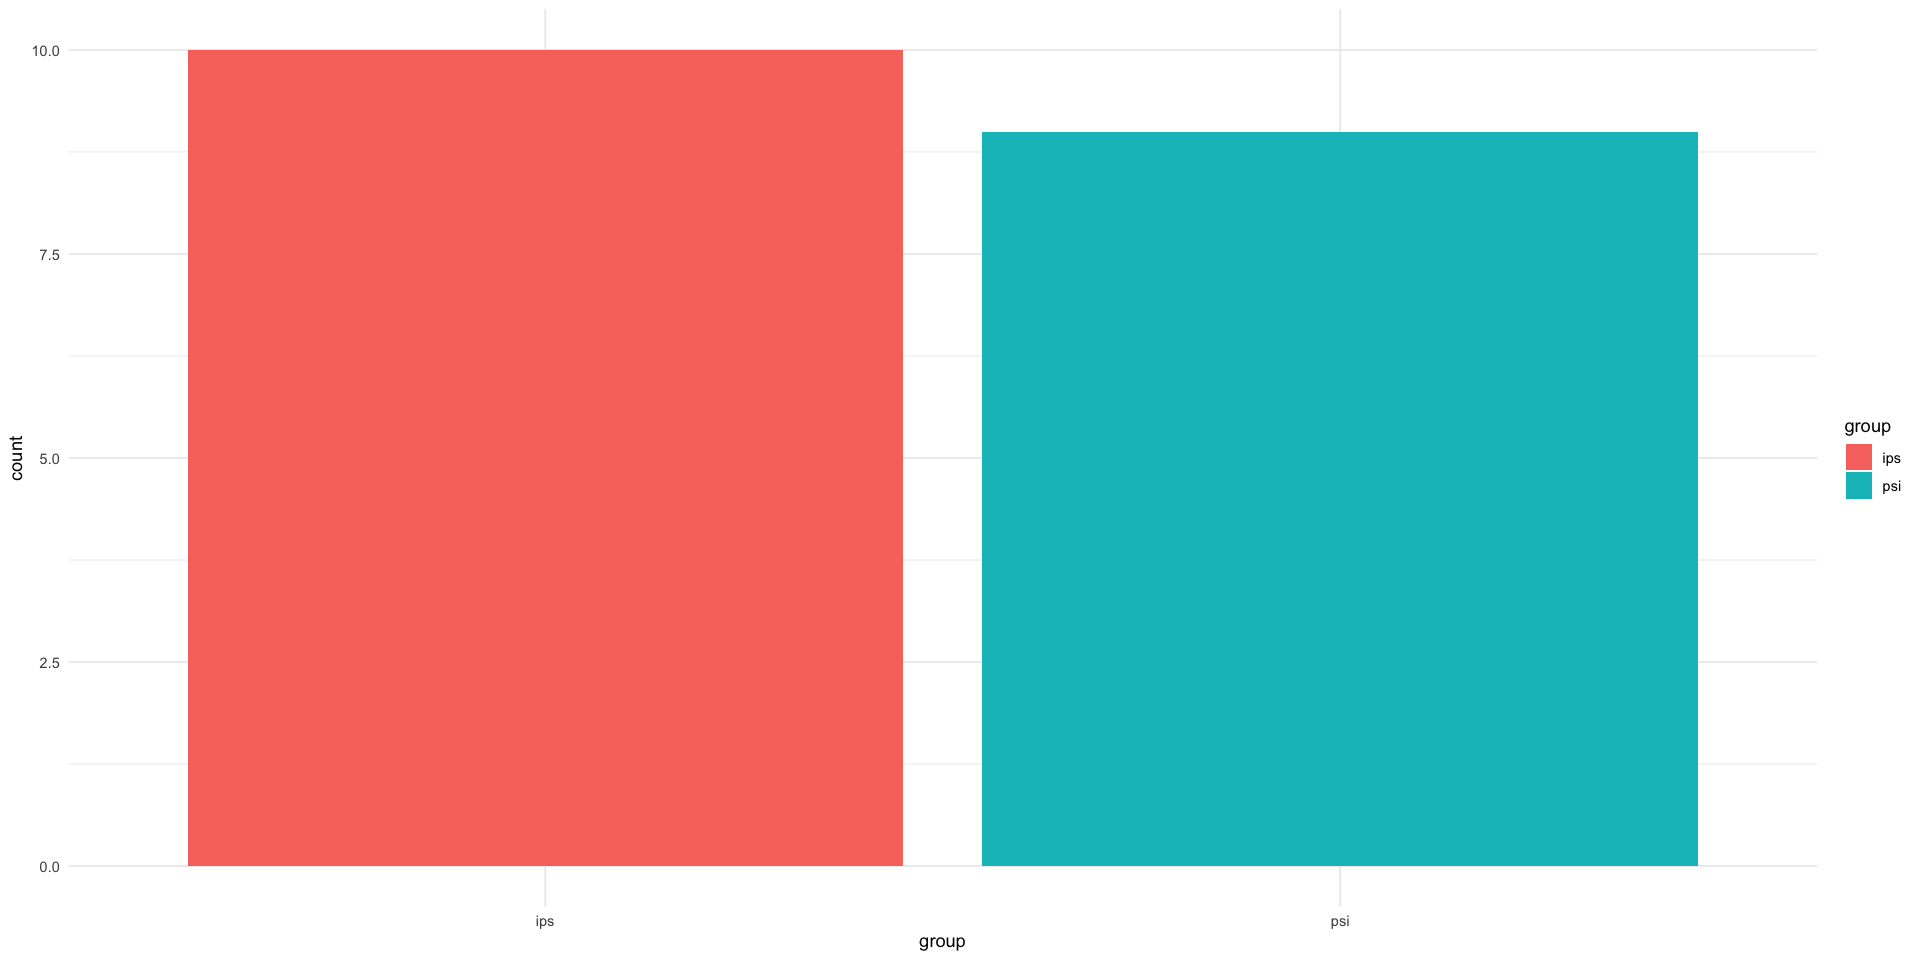

In [56]:
ggplot(df_combined, aes(x = group, fill = group)) +
  geom_bar() +
  theme_minimal()


In [57]:
summary(df_combined)

 time_posttest   grade_posttest     gender              age            academic_level     academic_field     parents_education     sport            time_pretest   grade_pretest   comfort_before 
 Min.   :133.0   Min.   :1.900   Length:19          Length:19          Length:19          Length:19          Length:19          Length:19          Min.   :171.0   Min.   :0.400   Min.   :1.000  
 1st Qu.:270.5   1st Qu.:5.800   Class :character   Class :character   Class :character   Class :character   Class :character   Class :character   1st Qu.:285.5   1st Qu.:4.000   1st Qu.:2.000  
 Median :354.0   Median :6.500   Mode  :character   Mode  :character   Mode  :character   Mode  :character   Mode  :character   Mode  :character   Median :438.0   Median :4.500   Median :2.000  
 Mean   :356.8   Mean   :6.779                                                                                                                     Mean   :470.6   Mean   :4.463   Mean   :2.389  
 3rd Qu.:419.5   3rd Qu.:

## Control variables

#### Gender and condition

In [58]:
# Create a contingency table of group (psi vs ips) vs gender
df_combined %>%
  tabyl(group, gender)

# Run a chi-squared test on the same contingency table
df_combined %>%
  tabyl(group, gender) %>%
  chisq.test()

group,Female,Male
<chr>,<dbl>,<dbl>
ips,6,4
psi,6,3


Warning message in stats::chisq.test(., ...):
“L’approximation du Chi-2 est peut-être incorrecte”



	Pearson's Chi-squared test with Yates' continuity correction

data:  .
X-squared = 0, df = 1, p-value = 1


The chi-squared test for gender shows no significant difference between the psi and ips groups (X² = 0, p = 1). This indicates that the groups are balanced with respect to this control variable, reducing the likelihood that it will confound the main analysis. Therefore, differences observed in the outcome are unlikely to be explained by this control variable.

#### Academic level and condition

In [59]:
df_combined %>%
  tabyl(group, academic_level) %>%
  chisq.test()

table(df_combined$group, df_combined$academic_level)

Warning message in stats::chisq.test(., ...):
“L’approximation du Chi-2 est peut-être incorrecte”



	Pearson's Chi-squared test

data:  .
X-squared = 2.9556, df = 4, p-value = 0.5653


     
      Bachelor Doctorate Got my MSc, currently PhD student Master bachelor second year
  ips        4         1                                 0      4                    1
  psi        4         0                                 1      4                    0

The chi-squared test shows that there is no statistically significant association between the groups and academic level.

#### Academic field and condition

In [60]:
df_combined %>%
  tabyl(group, academic_field) %>%
  chisq.test()

table(df_combined$group, df_combined$academic_field)

Warning message in stats::chisq.test(., ...):
“L’approximation du Chi-2 est peut-être incorrecte”



	Pearson's Chi-squared test

data:  .
X-squared = 19, df = 17, p-value = 0.3285


     
      Applied Mathematics Computer Science Computer Science (and Math for bachelor) Cybersecurity Economics Engineering and Entrepreneurship Environmental Laws and International Relations
  ips                   0                0                                        0             1         0                                1                                              0
  psi                   1                2                                        1             0         1                                0                                              1
     
      Environmental Science Life Sciences Engineering Mathematics Mechanical engineering Medical Biotechnology Medicine Micro-Engineering Neuro-X SIE Software Engineering microengineering
  ips                     0                         0           1                      1                     1        1                 1       1   0                    1                1
  psi                     1                     

The chi-squared test shows that there is no statistically significant association between the groups and academic field.

### Parents' education level and condition

In [61]:
df_combined %>%
  tabyl(group, parents_education) %>%
  chisq.test()

table(df_combined$group, df_combined$parents_education)

Warning message in stats::chisq.test(., ...):
“L’approximation du Chi-2 est peut-être incorrecte”



	Pearson's Chi-squared test

data:  .
X-squared = 3.9583, df = 2, p-value = 0.1382


     
      High school Primary school University
  ips           0              0         10
  psi           2              1          6

The chi-squared test shows that there is no statistically significant association between the groups and parents' academic level.

## Plots: Learning Gain by Group


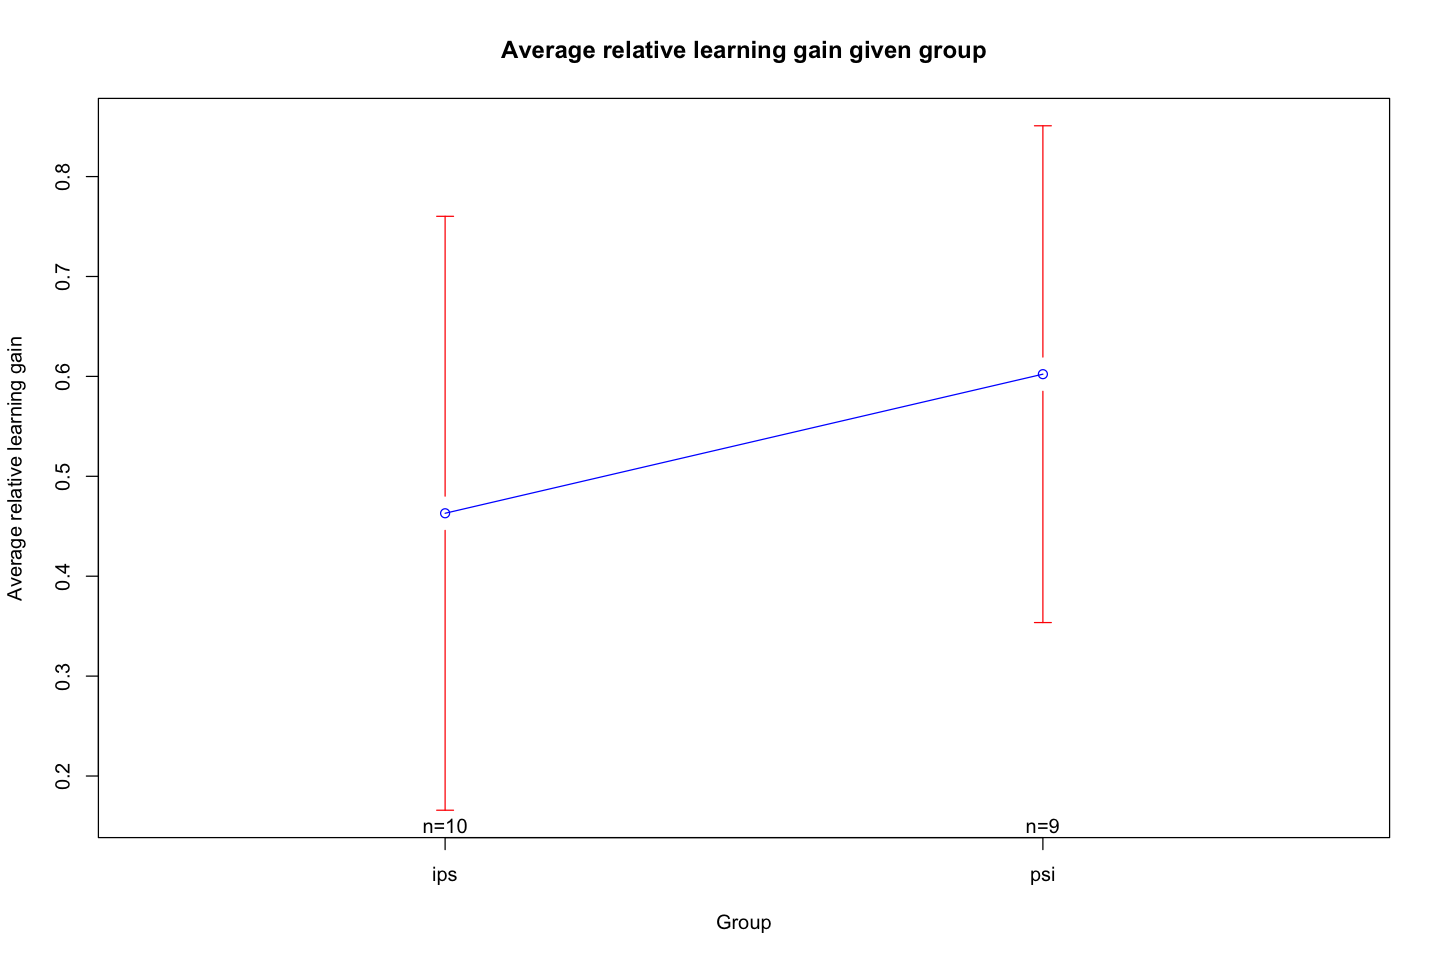

In [62]:
options(repr.plot.width=12, repr.plot.height=8)

# Set white background
par(bg = "white")

plotmeans(rel_learning_gain ~ group, 
          main="Average relative learning gain given group",
          ylab="Average relative learning gain",
          xlab="Group",
          data=df_combined,
          col="blue",
          barcol="red")

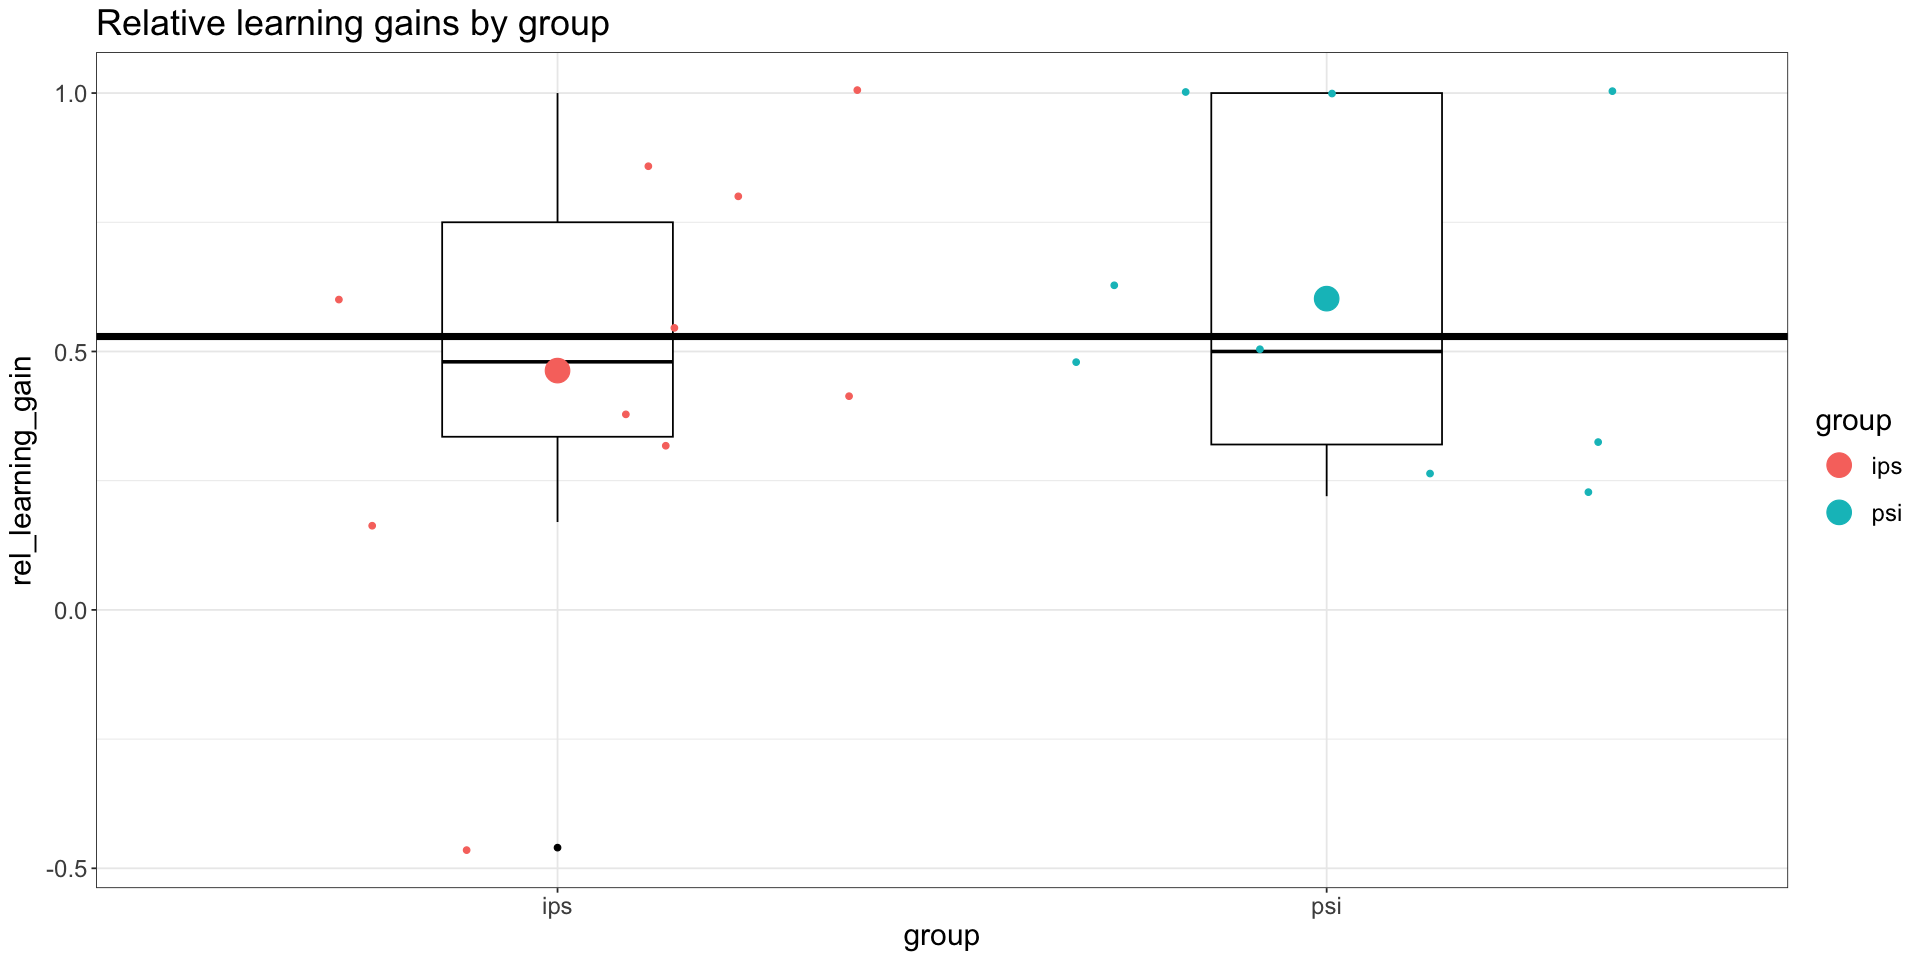

In [63]:
options(repr.plot.width=16, repr.plot.height=8)
df_combined %>% ggplot() +
    aes(x = group, y = rel_learning_gain, color = group) +
    geom_boxplot(color = "black", width = 0.3) +
    geom_jitter() +
    stat_summary(fun=mean, 
        #color="black",
        geom="point",
        group=1,
        shape=20, 
        size=10, 
    ) +
    theme_bw() +
    labs(title = "Relative learning gains by group") +
    theme(text = element_text(size = 18)) +
    geom_hline(aes(yintercept = mean(rel_learning_gain)), linewidth=2, color = "black") 

## ANOVA test with one factor

### Sum of squares

In [64]:
# Calculate the average relative learning gain
ave_rel_learning_gain = mean(df_combined$rel_learning_gain)
ave_rel_learning_gain

[1] 0.5289474

In [65]:
# Calculate the sum of squares total
ss_total = sum((df_combined$rel_learning_gain - ave_rel_learning_gain)^2)
ss_total

[1] 2.482579

In [66]:
# Calculate the sum of squares within groups
within_ss = function(x) {
    sum((x - mean(x))^2)
}
ss_within = sum(tapply(df_combined$rel_learning_gain, df_combined$group, within_ss))
ss_within

mss_within = ss_within / (length(df_combined$rel_learning_gain) - 2) # N - k groups
mss_within 

[1] 2.390766

[1] 0.1406333

In [67]:
# Calculate the sum of squares between groups
between_ss = function(x) {
    sum(length(x)*(mean(x) - ave_rel_learning_gain)^2)
}

ss_between = sum(tapply(df_combined$rel_learning_gain, df_combined$group, between_ss))
ss_between

mss_between = ss_between / 1 # (k groups - 1)
mss_between 

[1] 0.09181339

[1] 0.09181339

### F-ratio

In [68]:
# Compute the ratio of the between group variance to the within group variance
F = mss_between / mss_within
F

[1] 0.6528568

### p-value

In [69]:
# pf gives the probability of getting an F value greater than F
p.value = pf(F, 1, 198, lower.tail = FALSE)
p.value

[1] 0.4200628

In [70]:
no_obs = nrow(df_combined)
alpha = 0.05
F.critical = qf(1-alpha, df1=1, df2=no_obs - 2) 
F.critical

[1] 4.451322

The calculated F-value was 0.40, which is much smaller than the critical F-value of 4.54. The associated p-value was 0.53, well above the standard significance level of 0.05.

Therefore, we fail to reject the null hypothesis. This suggests that there is no statistically significant difference in relative learning gain between the two groups, and any observed variation is likely due to random chance.